# Tutorial: Why Scaling and Normalization Matters in Classification

Many classifiers depend on distances or feature magnitudes. If one feature ranges from `0–1` and another from `0–100,000`, gradient-based optimization can become slow or unstable.

This tutorial compares neural-network performance with and without feature scaling using the Breast Cancer dataset from scikit-learn.

---
## 1. Imports and data

In [2]:
from sklearn.datasets import load_breast_cancer

# Load the dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Feature matrix shape:", X.shape)
print("Classes:", data.target_names)
print("First 5 feature names:", data.feature_names[:5])

Feature matrix shape: (569, 30)
Classes: ['malignant' 'benign']
First 5 feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']



You should notice that feature ranges differ substantially. For example, one feature may have values around 0.05, while another may be in the thousands. This difference matters because neural networks use weighted sums:

$$ z = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b $$

A large-scale feature can dominate this calculation, even if it is not more important than other features.

---


In [4]:
for i, name in enumerate(data.feature_names[:10]):
    print(
        f"{name:25s} "
        f"min={X[:, i].min():10.4f} "
        f"max={X[:, i].max():10.4f}"
    )

mean radius               min=    6.9810 max=   28.1100
mean texture              min=    9.7100 max=   39.2800
mean perimeter            min=   43.7900 max=  188.5000
mean area                 min=  143.5000 max= 2501.0000
mean smoothness           min=    0.0526 max=    0.1634
mean compactness          min=    0.0194 max=    0.3454
mean concavity            min=    0.0000 max=    0.4268
mean concave points       min=    0.0000 max=    0.2012
mean symmetry             min=    0.1060 max=    0.3040
mean fractal dimension    min=    0.0500 max=    0.0974


## 2. Split the data

Always split before fitting a scaler. Otherwise, information from the test data can leak into training.



In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


---

## 3. Compare MLP with and without scaling

K-Nearest Neighbors (KNN) is strongly affected by scale because it classifies points based on distances.


In [9]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

models = {
    "No scaling": MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    ),

    "StandardScaler": Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    ))
    ]),

    "MinMaxScaler": Pipeline([
        ("scaler", MinMaxScaler()),
        ("mlp", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    ))
    ])
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    results[name] = accuracy_score(y_test, predictions)

#print(results)

results_df = pd.DataFrame.from_dict(
    results, orient="index", columns=["Accuracy"]
)

print(results_df)

                Accuracy
No scaling      0.881119
StandardScaler  0.965035
MinMaxScaler    0.972028


Your precise scores can vary slightly, but scaling should substantially improve KNN.

---

## 4. Visualize the difference


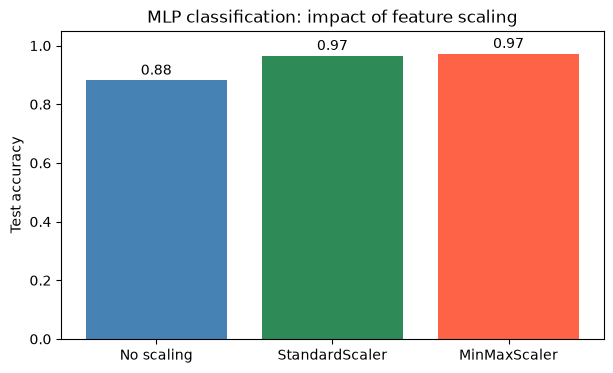

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(results_df.index, results_df["Accuracy"], color=["steelblue", "seagreen", "tomato"])
plt.ylim(0, 1.05)
plt.ylabel("Test accuracy")
plt.title("MLP classification: impact of feature scaling")

for i, value in enumerate(results_df["Accuracy"]):
    plt.text(i, value + 0.02, f"{value:.2f}", ha="center")

plt.show()

---

## 5. Compare the loss curves

The loss curve shows how the model’s optimization progressed over training.


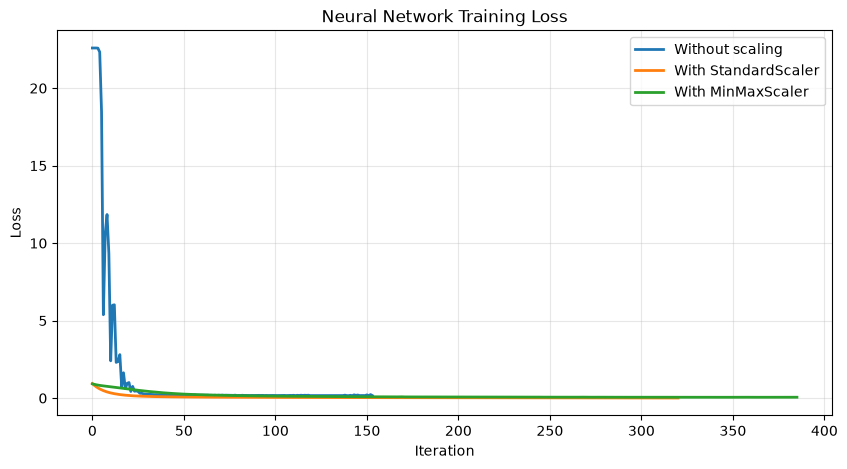

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    models["No scaling"].loss_curve_,
    label="Without scaling",
    linewidth=2
)

plt.plot(
    models["StandardScaler"].named_steps["mlp"].loss_curve_,
    label="With StandardScaler",
    linewidth=2
)

plt.plot(
    models["MinMaxScaler"].named_steps["mlp"].loss_curve_,
    label="With MinMaxScaler",
    linewidth=2
)

plt.title("Neural Network Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---

# 6. Some concluding remarks

`StandardScaler` transforms every feature so it has approximately:

- mean = `0`
- standard deviation = `1`

`MinMaxScaler` transforms every feature so it has scaled data to the interval 0-1:

- min = `0`
- max = `1`


This means no feature dominates simply because it was measured in larger units.

---



In [13]:
std_scaler = StandardScaler()
mM_scaler = MinMaxScaler()

std_X_train = std_scaler.fit_transform(X_train)
mM_X_train  = mM_scaler.fit_transform(X_train)
std_scaled_df = pd.DataFrame(std_X_train, columns=data.feature_names)
mM_scaled_df = pd.DataFrame(mM_X_train, columns=data.feature_names)

print("========================= StandardScaler ===========================")
print(std_scaled_df.describe().loc[["mean", "std"]].round(2))
print("\n Feature ranges:")
print(pd.DataFrame({
    "min": std_scaled_df.min(),
    "max": std_scaled_df.max(),
    "range": std_scaled_df.max() - std_scaled_df.min()
}).round(2))
print("====================================================")

print("========================= MinMaxScaler ===========================")

print(mM_scaled_df.describe().loc[["mean", "std"]].round(2))
print("\n Feature ranges:")
print(pd.DataFrame({
    "min": mM_scaled_df.min(),
    "max": mM_scaled_df.max(),
    "range": mM_scaled_df.max() - mM_scaled_df.min()
}).round(2))
print("====================================================")



========================= StandardScaler ===========================
      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
mean         -0.0           0.0            -0.0        0.0             -0.0   
std           1.0           1.0             1.0        1.0              1.0   

      mean compactness  mean concavity  mean concave points  mean symmetry  \
mean              -0.0            -0.0                  0.0           -0.0   
std                1.0             1.0                  1.0            1.0   

      mean fractal dimension  ...  worst radius  worst texture  \
mean                     0.0  ...          -0.0            0.0   
std                      1.0  ...           1.0            1.0   

      worst perimeter  worst area  worst smoothness  worst compactness  \
mean              0.0        -0.0               0.0               -0.0   
std               1.0         1.0               1.0                1.0   

      worst concavity  worst concave

# Key takeaways

| Technique | What it does | Good use cases |
|---|---|---|
| `StandardScaler` | Centers features at 0 and scales them to unit variance | SVM, KNN, logistic regression, PCA, neural networks |
| `MinMaxScaler` | Maps features into a fixed range, usually `[0, 1]` | Neural networks, bounded input features |
| No scaling | Keeps original units | Often acceptable for decision trees and random forests |

## Models that usually benefit from scaling

- K-Nearest Neighbors
- Support Vector Machines
- Logistic Regression
- Neural Networks
- Principal Component Analysis
- K-Means clustering

## Models that usually do *not* need scaling

- Decision Trees
- Random Forests
- Gradient-Boosted Trees (such as XGBoost or LightGBM)

These tree-based methods split features by thresholds, rather than comparing feature distances.

---

## Important best practice: use a Pipeline

This is correct:

```python
Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])
```

Avoid scaling the entire dataset *before* splitting it:

```python
# Avoid this: test-set information leaks into training
X_scaled = StandardScaler().fit_transform(X)
```

A `Pipeline` ensures the scaler learns statistics only from the training fold during fitting and cross-validation.